In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.tree import plot_tree
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
california_housing = fetch_california_housing()


In [ ]:
california_housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [ ]:
df = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)

In [ ]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [ ]:
df['MedHouseVal'] = california_housing.target

In [ ]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [ ]:
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {len(california_housing.feature_names)}")
print(f"Feature names: {california_housing.feature_names}")
print(f"Target variable: MedHouseVal (Median House Value)")

print("\nFirst 5 rows of the dataset:")
df.head()

Dataset shape: (20640, 9)
Number of features: 8
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target variable: MedHouseVal (Median House Value)

First 5 rows of the dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
print("Basic statistics of the dataset:")
df.describe()

Basic statistics of the dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


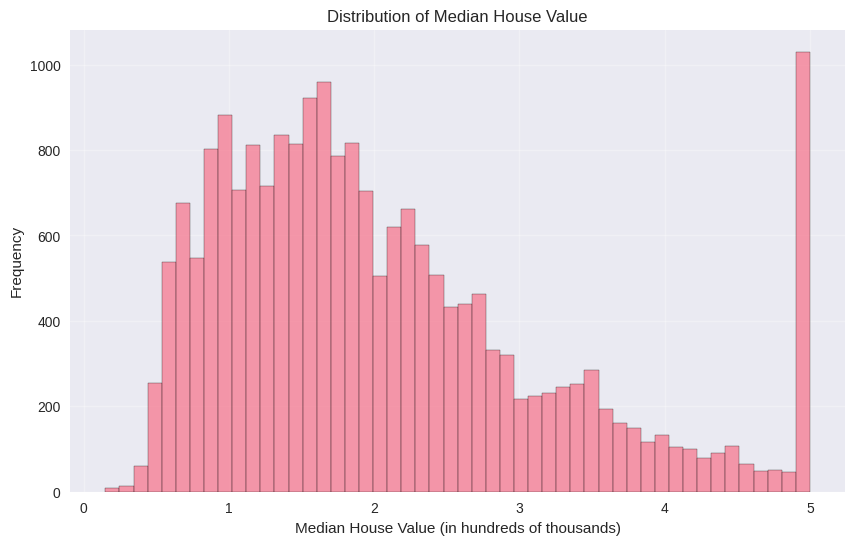

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['MedHouseVal'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value (in hundreds of thousands)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
print(f"Mean house value: ${df['MedHouseVal'].mean()*100:.2f}k")
print(f"Median house value: ${df['MedHouseVal'].median()*100:.2f}k")
print(f"Standard deviation: ${df['MedHouseVal'].std()*100:.2f}k")

Mean house value: $206.86k
Median house value: $179.70k
Standard deviation: $115.40k


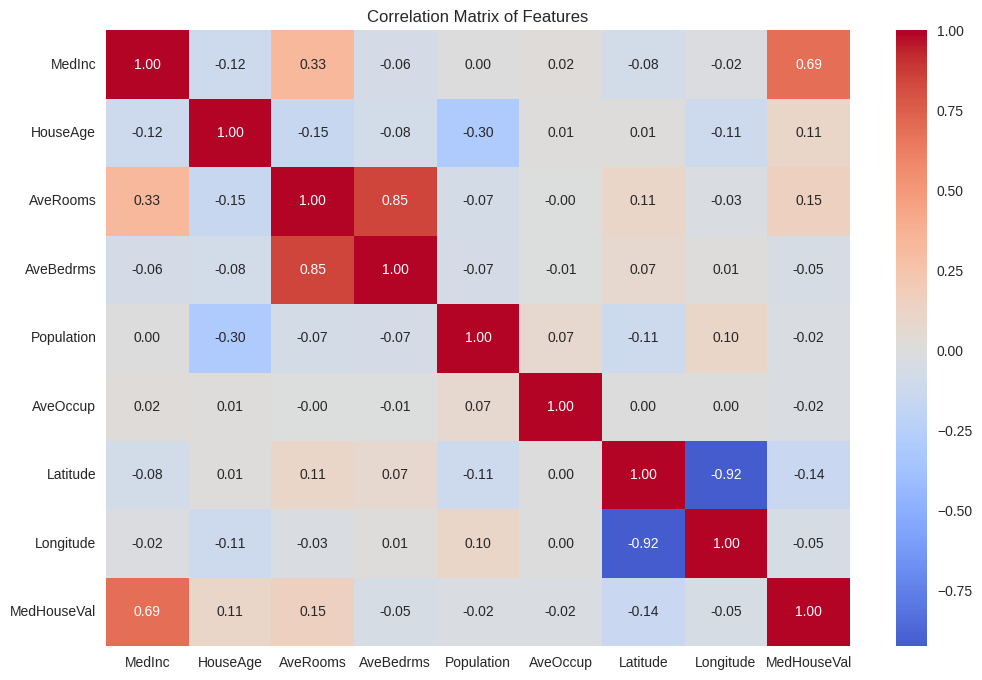

In [ ]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

In [ ]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

Training set size: 16512 samples
Testing set size: 4128 samples
Number of features: 8


In [ ]:
dt_regressor = DecisionTreeRegressor(max_depth=10, random_state=42)

In [ ]:
dt_regressor.fit(X_train, y_train)

print("Decision Tree Regressor trained successfully!")
print(f"Tree depth: {dt_regressor.get_depth()}")
print(f"Number of leaves: {dt_regressor.get_n_leaves()}")

Decision Tree Regressor trained successfully!
Tree depth: 10
Number of leaves: 788


In [ ]:
print("Decision Tree Regressor trained successfully!")
print(f"Tree depth: {dt_regressor.get_depth()}")
print(f"Number of leaves: {dt_regressor.get_n_leaves()}")

Decision Tree Regressor trained successfully!
Tree depth: 10
Number of leaves: 788


In [ ]:
y_pred = dt_regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [ ]:
print("Model Performance Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (R²): {r2:.4f}")
print(f"\nInterpretation: Our model explains {r2*100:.2f}% of the variance in house prices.")

Model Performance Metrics:
Mean Squared Error (MSE): 0.4155
Root Mean Squared Error (RMSE): 0.6446
R-squared Score (R²): 0.6829

Interpretation: Our model explains 68.29% of the variance in house prices.


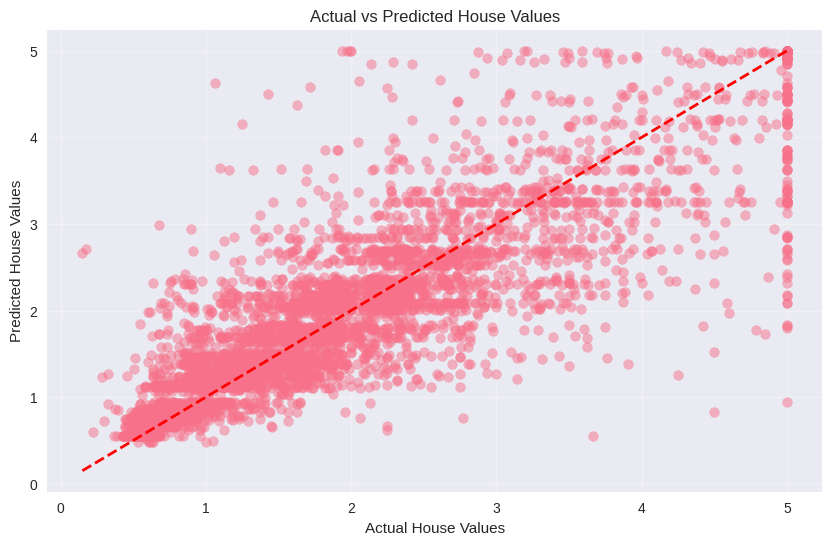

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual House Values')
plt.ylabel('Predicted House Values')
plt.title('Actual vs Predicted House Values')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
residuals = y_test - y_pred

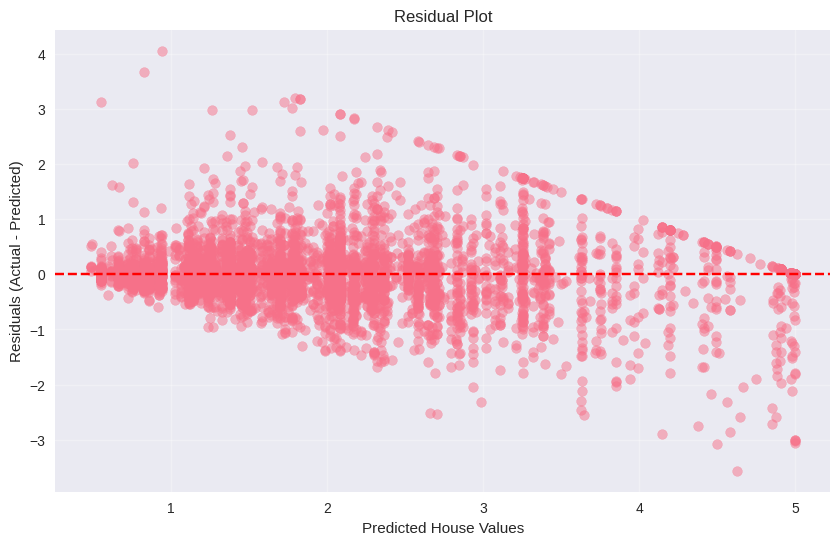

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted House Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)
plt.show()

Feature Importances:
      Feature  Importance
0      MedInc    0.609776
5    AveOccup    0.131055
6    Latitude    0.080960
7   Longitude    0.065139
1    HouseAge    0.044300
2    AveRooms    0.039228
4  Population    0.016760
3   AveBedrms    0.012783


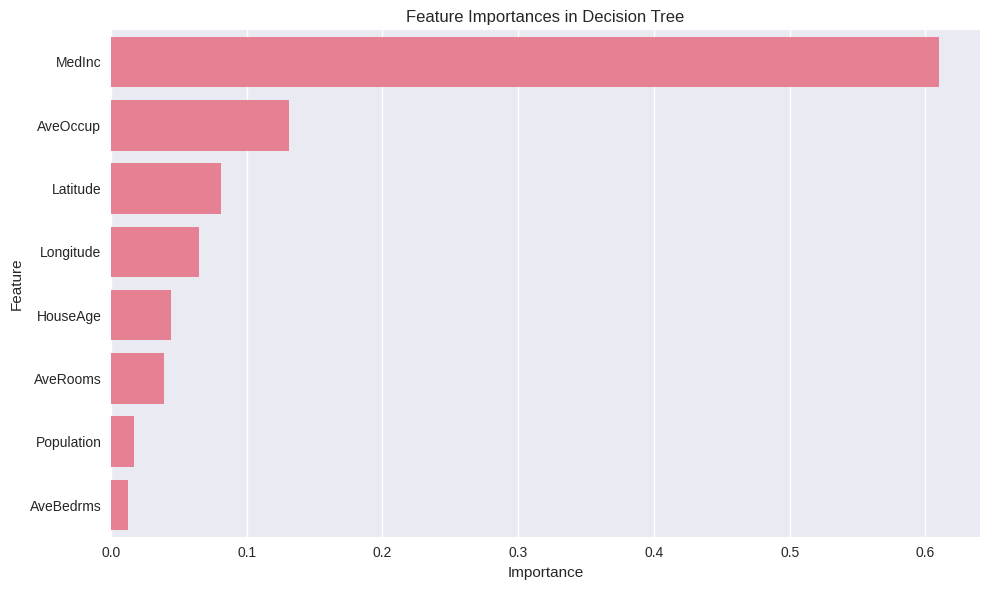

In [ ]:
feature_importance = dt_regressor.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Feature Importances in Decision Tree')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

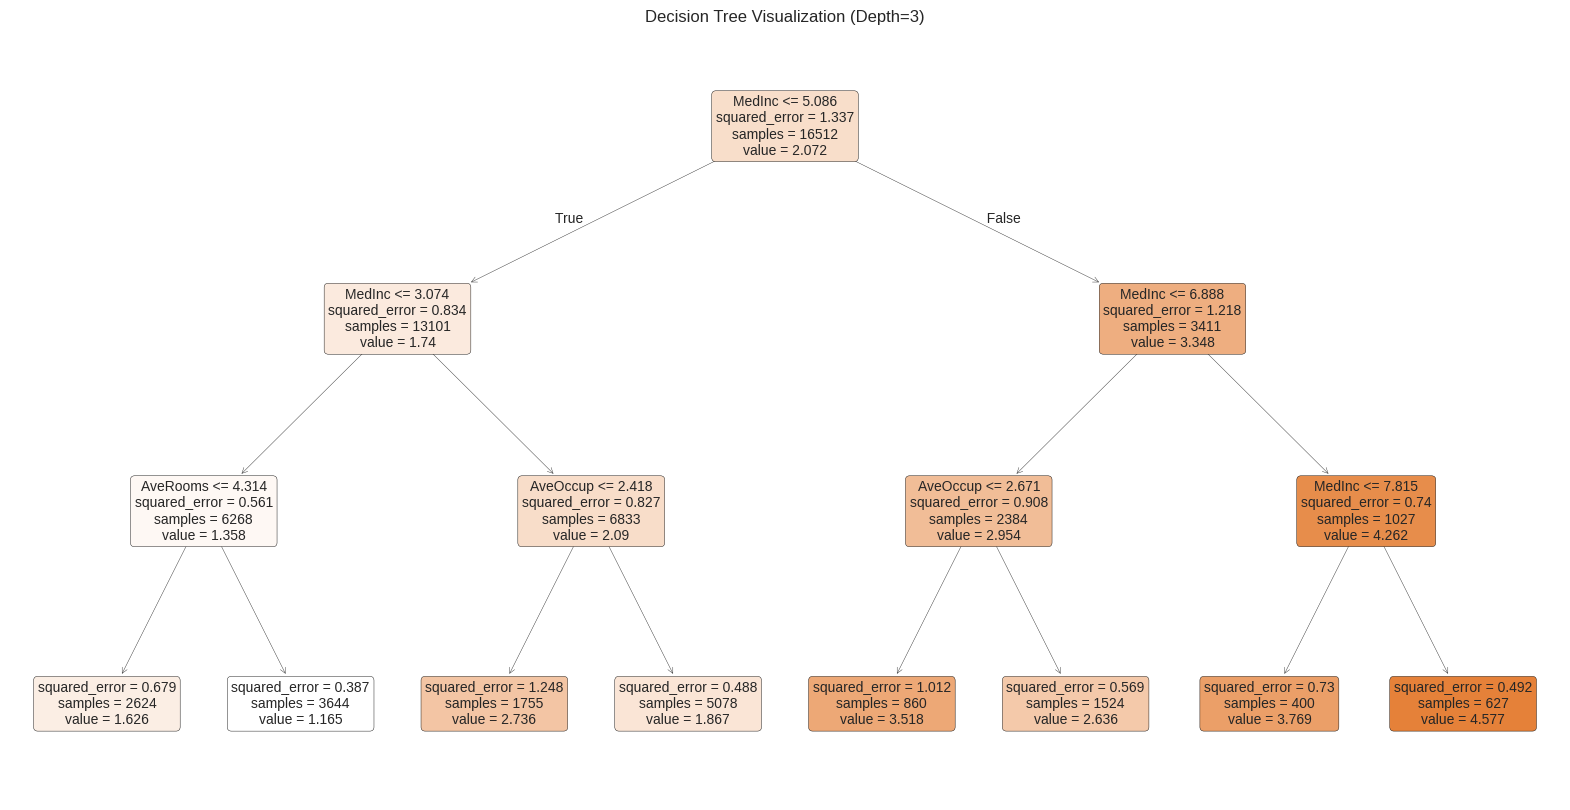

In [ ]:
simple_dt = DecisionTreeRegressor(max_depth=3, random_state=42)
simple_dt.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(simple_dt,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Visualization (Depth=3)')
plt.show()

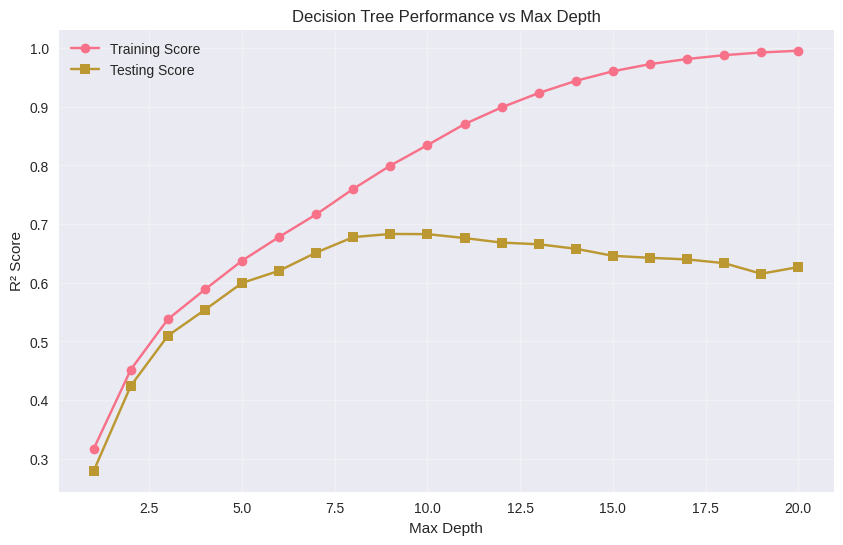

Best max_depth: 9
Best R² score: 0.6833


In [ ]:
max_depths = range(1, 21)
train_scores = []
test_scores = []

for depth in max_depths:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    train_score = dt.score(X_train, y_train)
    test_score = dt.score(X_test, y_test)

    train_scores.append(train_score)
    test_scores.append(test_score)

plt.figure(figsize=(10, 6))
plt.plot(max_depths, train_scores, label='Training Score', marker='o')
plt.plot(max_depths, test_scores, label='Testing Score', marker='s')
plt.xlabel('Max Depth')
plt.ylabel('R² Score')
plt.title('Decision Tree Performance vs Max Depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_depth = max_depths[np.argmax(test_scores)]
best_score = max(test_scores)
print(f"Best max_depth: {best_depth}")
print(f"Best R² score: {best_score:.4f}")

In [ ]:
mean_pred = np.full_like(y_test, y_train.mean())
baseline_mse = mean_squared_error(y_test, mean_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, mean_pred)

print("Baseline Model (Mean Predictor) Performance:")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"R² Score: {baseline_r2:.4f}")

print("\nDecision Tree Model Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

improvement = (baseline_rmse - rmse) / baseline_rmse * 100
print(f"\nImprovement over baseline: {improvement:.2f}% reduction in RMSE")

Baseline Model (Mean Predictor) Performance:
RMSE: 1.1449
R² Score: -0.0002

Decision Tree Model Performance:
RMSE: 0.6446
R² Score: 0.6829

Improvement over baseline: 43.70% reduction in RMSE


In [ ]:
median_value = df['MedHouseVal'].median()
y_class = (df['MedHouseVal'] > median_value).astype(int)

df['PriceCategory'] = y_class
df['PriceLabel'] = df['PriceCategory'].map({0: 'Affordable', 1: 'Expensive'})

print(f"Median house value: ${median_value*100:.2f}k")
print(f"Number of affordable houses: {sum(y_class == 0)}")
print(f"Number of expensive houses: {sum(y_class == 1)}")

Median house value: $179.70k
Number of affordable houses: 10323
Number of expensive houses: 10317


In [ ]:
X_class = df.drop(['MedHouseVal', 'PriceCategory', 'PriceLabel'], axis=1)
y_class = df['PriceCategory']

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

dt_classifier = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_classifier.fit(X_train_class, y_train_class)

y_pred_class = dt_classifier.predict(X_test_class)

accuracy = accuracy_score(y_test_class, y_pred_class)
print(f"Classification Accuracy: {accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_class, y_pred_class, target_names=['Affordable', 'Expensive']))

Classification Accuracy: 0.8561

Classification Report:
              precision    recall  f1-score   support

  Affordable       0.86      0.86      0.86      2077
   Expensive       0.86      0.85      0.86      2051

    accuracy                           0.86      4128
   macro avg       0.86      0.86      0.86      4128
weighted avg       0.86      0.86      0.86      4128

